# 03 · Pass 2 — grid search (LightGBM & CatBoost)

Grid-tune the two Pass-1 co-leaders and evaluate the best estimator on the held-out test
set. This notebook surfaces the grids, then the result — including a finding that matters
methodologically.

In [1]:
# --- make the benchmark/ package importable from notebooks/ ---
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / 'benchmark').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print('project root:', ROOT)

project root: D:\_fcall\UNIFEI\tcc\hpc_workload


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'font.family': 'DejaVu Sans',
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.8,
    'axes.edgecolor': '#c3c2b7', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.labelcolor': '#52514e', 'text.color': '#0b0b0b', 'figure.facecolor': 'white',
})
BLUE, MUTED, BAD, LIGHTBLUE = '#2a78d6', '#898781', '#d03b3b', '#9ec5f4'

In [3]:
import benchmark.config as C
from benchmark.grids import get_grids
import numpy as np, pandas as pd, json

y_train = np.load(C.artifact_path('y_train'))
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
grids = get_grids(scale_pos_weight)

## The grids searched

In [4]:
for name in ['LightGBM', 'CatBoost']:
    g = grids[name].param_grid
    n = 1
    for v in g.values():
        n *= len(v)
    print(f'{name}:  {n} candidates x 3 folds = {n * 3} fits')
    for k, v in g.items():
        print(f'    {k}: {v}')
    print()

LightGBM:  36 candidates x 3 folds = 108 fits
    num_leaves: [15, 31, 63]
    learning_rate: [0.05, 0.1]
    n_estimators: [200, 500]
    min_child_samples: [20, 100, 500]
    scale_pos_weight: [30.260087827469036]

CatBoost:  12 candidates x 3 folds = 36 fits
    depth: [4, 6, 8]
    learning_rate: [0.05, 0.1]
    iterations: [300, 500]



## Grid search (gated)

`GridSearchCV(StratifiedKFold(3, shuffle, seed=42), scoring='average_precision')`, run
`n_jobs=1` so the training matrix is never duplicated (RAM-safe). Gated — the real run is
~4 h. Flip `RUN_GRID = True` to reproduce.

In [5]:
RUN_GRID = False
if RUN_GRID:
    import benchmark.run_pass2 as R2
    R2.run(explicit='LightGBM,CatBoost')
else:
    print('Loading precomputed Pass-2 rows + results/pass2_grid_results/.')

Loading precomputed Pass-2 rows + results/pass2_grid_results/.


## Base vs. grid-tuned

In [6]:
df = pd.read_csv(C.RESULTS_CSV).drop_duplicates(['model', 'pass'], keep='last')
rows = []
for m in ['LightGBM', 'CatBoost']:
    b = float(df[(df['pass'] == 1) & (df['model'] == m)]['pr_auc'].iloc[0])
    t = float(df[(df['pass'] == 2) & (df['model'] == m)]['pr_auc'].iloc[0])
    cv = float(pd.read_csv(C.PASS2_DIR / f'{m}_cv_results.csv')['mean_test_score'].max())
    bp = json.load(open(C.PASS2_DIR / f'{m}_best_params.json'))
    rows.append({'model': m, 'base_test': b, 'tuned_test': t, 'delta': t - b,
                 'best_cv_AP': cv, 'best_params': json.dumps(bp)})
comp = pd.DataFrame(rows)
comp

,model,base_test,tuned_test,delta,best_cv_AP,best_params
0,LightGBM,0.079296,0.061153,-0.018144,0.714199,"{""learning_rate"": 0.1, ""min_child_samples"": 20..."
1,CatBoost,0.079467,0.069653,-0.009814,0.618441,"{""depth"": 8, ""iterations"": 500, ""learning_rate..."


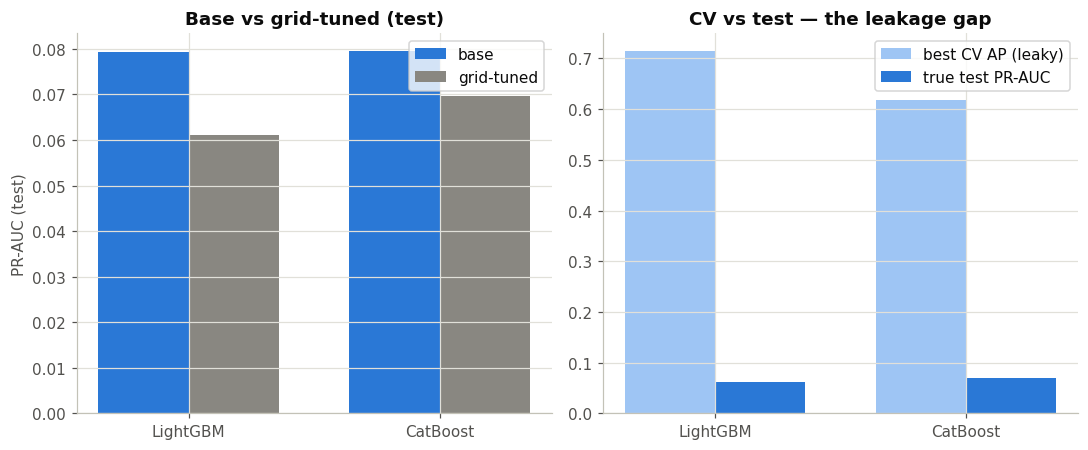

In [7]:
import numpy as np
x, w = np.arange(len(comp)), 0.36
fig, (axa, axb) = plt.subplots(1, 2, figsize=(10, 4.2))
axa.bar(x - w/2, comp['base_test'], w, color=BLUE, label='base')
axa.bar(x + w/2, comp['tuned_test'], w, color=MUTED, label='grid-tuned')
axa.set_xticks(x); axa.set_xticklabels(comp['model']); axa.set_ylabel('PR-AUC (test)')
axa.set_title('Base vs grid-tuned (test)'); axa.legend()
axb.bar(x - w/2, comp['best_cv_AP'], w, color=LIGHTBLUE, label='best CV AP (leaky)')
axb.bar(x + w/2, comp['tuned_test'], w, color=BLUE, label='true test PR-AUC')
axb.set_xticks(x); axb.set_xticklabels(comp['model'])
axb.set_title('CV vs test — the leakage gap'); axb.legend()
fig.tight_layout(); plt.show()

**Finding.** Grid tuning made both models **worse** on the test set. The mandated
`StratifiedKFold(shuffle)` splits *windows* at random, but consecutive windows overlap
39/40 snapshots and share a job — near-duplicate rows land in both train and validation
folds, inflating CV to **AP ≈ 0.62–0.71 vs true test ≈ 0.06**. The search therefore
selected the *most complex* settings (LightGBM `num_leaves=63`/`500 trees`; CatBoost
`depth=8`/`500 iters`), which overfit the temporal test set.

**Fix:** `GroupKFold(groups=slurm_id)` so no job spans folds — that's why we kept
`job_ids_train.npy`.